Import des differentes bibliotheques

In [7]:
from keras.models import Sequential
from keras. layers import Dense
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from main import *

données chargées : 
<bound method NDFrame.head of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

 

Import des differentes données

In [19]:
data = pd.read_csv("données_transformées.csv", sep=";", skiprows=[0])

datatarget = data.iloc[:,-1]
dataclean = data.iloc[:,:-1]



Sepration des données

In [20]:
X_train, X_test, y_train, y_test = train_test_split(dataclean,datatarget, test_size=0.2, random_state=42)

scale les entrées

In [21]:
print("Taille de X_train :", X_train.shape)
print("Types des colonnes :\n", X_train.dtypes)

scaler =StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Taille de X_train : (518, 30)
Types des colonnes :
 0      int64
0.1    int64
18     int64
0.2    int64
0.3    int64
1      int64
4      int64
4.1    int64
3      int64
0.4    int64
2      int64
1.1    int64
2.1    int64
2.2    int64
0.5    int64
0.6    int64
1.2    int64
1.3    int64
1.4    int64
0.7    int64
0.8    int64
1.5    int64
1.6    int64
4.2    int64
3.1    int64
4.3    int64
1.7    int64
1.8    int64
3.2    int64
4.4    int64
dtype: object


CREATION du reseau MLP avec une seul note 

In [22]:
Model1 = Sequential()
Model1.add(Dense(10, activation='relu', input_dim=30))
Model1.add(Dense(5, activation='relu'))
Model1.add(Dense(1, activation='sigmoid'))

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
Model2 = Sequential()
Model2.add(Dense(5, activation='relu', input_dim=30))
Model2.add(Dense(3, activation='relu'))
Model2.add(Dense(1, activation='sigmoid'))

In [24]:
Model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
Model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
Model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
Model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177 (708.00 B)

 Trainable params: 177 (708.00 B)

 Non-trainable params: 0 (0.00 B)

apprentissage

In [45]:
epochs = 1000
history1 = Model1.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2  # ou validation_data=(X_val, y_val)
)
history2=Model2.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2  # ou validation_data=(X_val, y_val)
)

Epoch 1/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6208 - loss: 12.2767 - val_accuracy: 0.4615 - val_loss: 8.3780
Epoch 2/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5362 - loss: 5.3690 - val_accuracy: 0.5673 - val_loss: 3.8743
Epoch 3/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6691 - loss: 2.6764 - val_accuracy: 0.6154 - val_loss: 3.2461
Epoch 4/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6836 - loss: 2.1545 - val_accuracy: 0.6154 - val_loss: 2.7733
Epoch 5/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7150 - loss: 1.9723 - val_accuracy: 0.6250 - val_loss: 2.5552
Epoch 6/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7005 - loss: 1.8537 - val_accuracy: 0.6154 - val_loss: 2.4591
Epoch 7/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7222 - loss: 1.6676 - val_accuracy: 0.6154 - val_loss: 2.2377
Epoch 8/1000
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7174 - loss: 1.5524 - val_accuracy: 

Prediction des notes

In [46]:
Predict1 = Model1.predict(X_test_scaled)
Predict2 = Model2.predict(X_test_scaled)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


presentation de la loss fonction durant l apprentissage

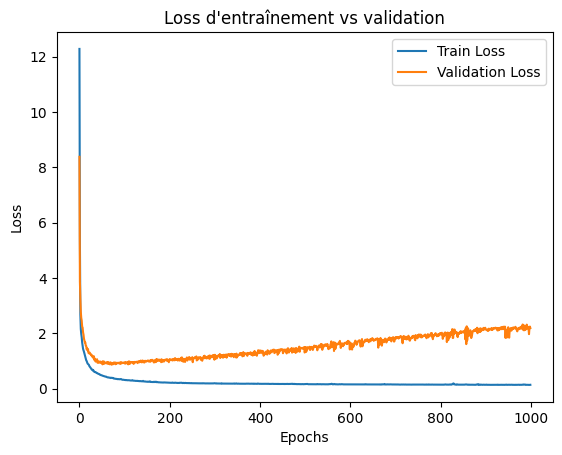

In [52]:
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')

plt.title("Loss d'entraînement vs validation")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

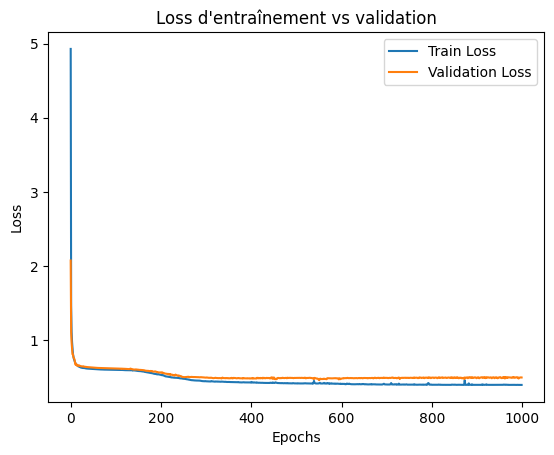

In [53]:
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.title("Loss d'entraînement vs validation")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

fonction de la matrice de confusion

In [54]:
def afficher_matrice_confusion(cm,Type_model):
    """Affiche la matrice de confusion."""
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title(f'Matrice de Confusion - {Type_model}')
    plt.show()






In [55]:
predictions_binary1 = (Predict1 > 0.5).astype(int)
predictions_binary2 = (Predict2 > 0.5).astype(int)


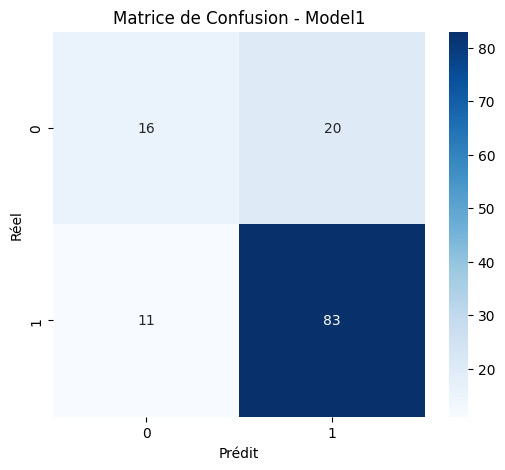

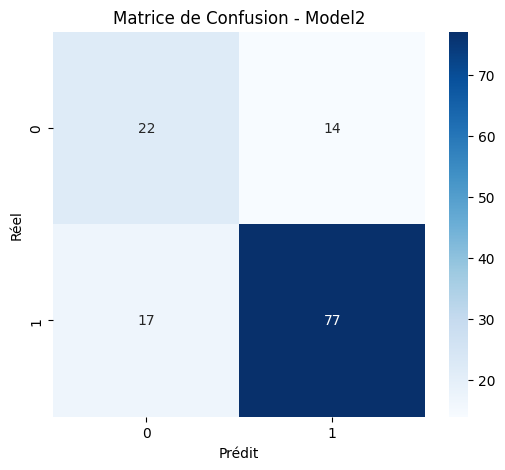

In [56]:

cm1 = confusion_matrix(y_test, predictions_binary1)
afficher_matrice_confusion(cm1,'Model1')


cm2 = confusion_matrix(y_test, predictions_binary2)
afficher_matrice_confusion(cm2,'Model2')